# Linear Regression from Scratch

**Dataset:** Diabetes (sklearn built-in)  
**Task:** Regression — predict disease progression from clinical measurements

---

## Overview

**Linear regression** models the relationship between input features $\mathbf{x} \in \mathbb{R}^p$ and a continuous target $y \in \mathbb{R}$ as a linear function:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b = w_1 x_1 + w_2 x_2 + \cdots + w_p x_p + b$$

### The Normal Equation (Closed-Form Solution)

We minimize **Mean Squared Error**:

$$\text{MSE} = \frac{1}{n}\|\mathbf{y} - X\boldsymbol{\theta}\|^2$$

Setting the gradient to zero yields the **Normal Equation**:

$$\boldsymbol{\theta}^* = (X^\top X)^{-1} X^\top \mathbf{y}$$

When $X^\top X$ is singular (non-invertible), we use the **pseudoinverse** $(X^\top X)^+$, which handles multicollinear features gracefully.

### Ridge Regression (L2 Regularization)

To prevent overfitting on high-dimensional data, add an L2 penalty on the weights:

$$\boldsymbol{\theta}^*_{\text{ridge}} = (X^\top X + \lambda I)^{-1} X^\top \mathbf{y}$$

The $\lambda I$ term makes the matrix always invertible and shrinks coefficients toward zero.

### Evaluation Metrics

- **RMSE** — Root Mean Squared Error: $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ (in the same units as $y$)
- **R²** — Coefficient of Determination: $1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$ (fraction of variance explained; 1 = perfect)

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 12

## 2. Load and Explore the Diabetes Dataset

In [2]:
data = load_diabetes()
X, y = data.data, data.target
feature_names = data.feature_names

print(f"Samples: {X.shape[0]}, Features: {X.shape[1]}")
print(f"Features: {feature_names}")
print(f"Target (disease progression): min={y.min():.0f}, max={y.max():.0f}, mean={y.mean():.1f}")

Samples: 442, Features: 10
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Target (disease progression): min=25, max=346, mean=152.1


In [3]:
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df.describe().round(3)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000,442.000
mean,-0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,152.133
std,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,0.048,77.093
min,-0.107,-0.045,-0.090,-0.112,-0.127,-0.116,-0.102,-0.076,-0.126,-0.138,25.000
25%,-0.037,-0.045,-0.034,-0.037,-0.034,-0.030,-0.035,-0.039,-0.033,-0.033,87.000
50%,0.005,-0.045,-0.007,-0.006,-0.004,-0.004,-0.007,-0.003,-0.002,-0.001,140.500
75%,0.038,0.051,0.031,0.036,0.028,0.030,0.029,0.034,0.032,0.028,211.500
max,0.111,0.051,0.171,0.132,0.154,0.199,0.181,0.185,0.134,0.136,346.000


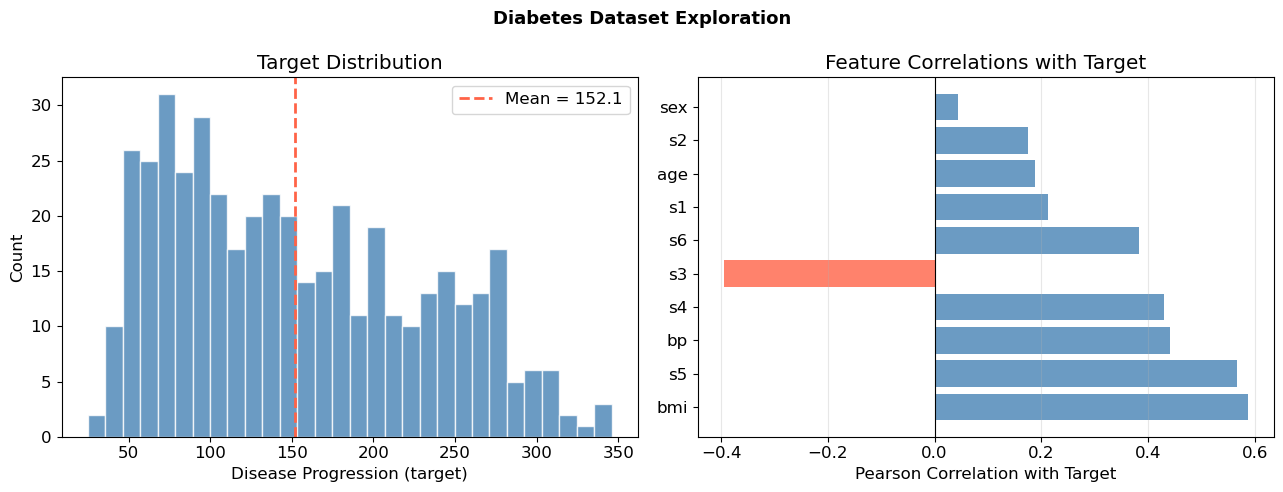

In [4]:
# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(y, bins=30, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(y.mean(), color='tomato', linestyle='--', lw=2, label=f'Mean = {y.mean():.1f}')
axes[0].set_xlabel('Disease Progression (target)')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution')
axes[0].legend()

# Correlation of each feature with the target
corrs = [np.corrcoef(X[:, i], y)[0, 1] for i in range(X.shape[1])]
sorted_idx = np.argsort(np.abs(corrs))[::-1]

bar_colors = ['tomato' if c < 0 else 'steelblue' for c in np.array(corrs)[sorted_idx]]
axes[1].barh(range(len(feature_names)), np.array(corrs)[sorted_idx], color=bar_colors, alpha=0.8)
axes[1].set_yticks(range(len(feature_names)))
axes[1].set_yticklabels(np.array(feature_names)[sorted_idx])
axes[1].set_xlabel('Pearson Correlation with Target')
axes[1].set_title('Feature Correlations with Target')
axes[1].axvline(0, color='black', lw=0.8)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Diabetes Dataset Exploration', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Simple Linear Regression (1 Feature)

We first fit a simple model using only the strongest predictor — `bmi` — to visualize the regression line.

In [5]:
bmi_idx = list(feature_names).index('bmi')
X_bmi = X[:, bmi_idx].reshape(-1, 1)

# Normal Equation: θ = (XᵀX)⁺ Xᵀy
X_bmi_aug = np.hstack([X_bmi, np.ones((len(X_bmi), 1))])  # add bias column
theta = np.linalg.pinv(X_bmi_aug.T @ X_bmi_aug) @ X_bmi_aug.T @ y

w, b = theta[0], theta[1]
print(f"Coefficient (bmi): {w:.4f}")
print(f"Intercept:         {b:.4f}")

y_pred_simple = X_bmi_aug @ theta
r2   = r2_score(y, y_pred_simple)
rmse = np.sqrt(mean_squared_error(y, y_pred_simple))
print(f"R²: {r2:.4f}  |  RMSE: {rmse:.2f}")

Coefficient (bmi): 949.4353
Intercept:         152.1335
R²: 0.3439  |  RMSE: 62.37


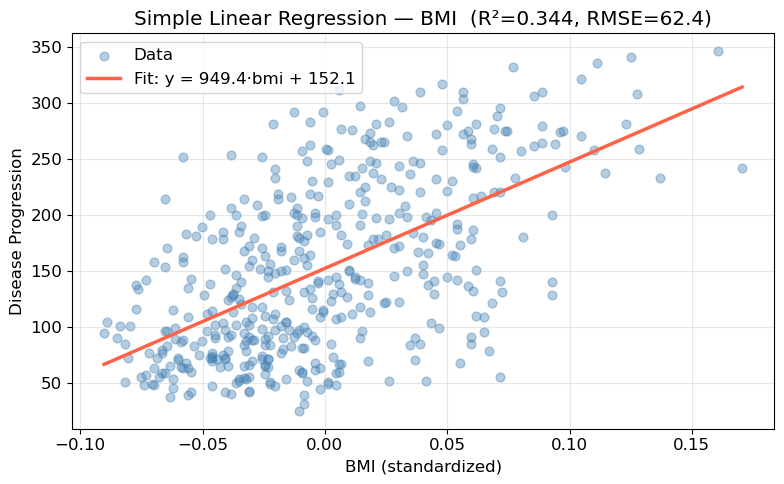

In [6]:
x_line = np.linspace(X_bmi.min(), X_bmi.max(), 200)
y_line = w * x_line + b

plt.figure(figsize=(8, 5))
plt.scatter(X_bmi, y, alpha=0.4, color='steelblue', s=40, label='Data')
plt.plot(x_line, y_line, color='tomato', lw=2.5, label=f'Fit: y = {w:.1f}·bmi + {b:.1f}')
plt.xlabel('BMI (standardized)')
plt.ylabel('Disease Progression')
plt.title(f'Simple Linear Regression — BMI  (R²={r2:.3f}, RMSE={rmse:.1f})')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Multiple Linear Regression from Scratch

Now we use all 10 features.

In [7]:
class LinearRegressionScratch:
    """Multiple linear regression via the Normal Equation."""

    def fit(self, X, y):
        n = X.shape[0]
        # Augment with bias column
        X_aug = np.hstack([X, np.ones((n, 1))])
        # Normal Equation with pseudoinverse for numerical stability
        self.theta_ = np.linalg.pinv(X_aug.T @ X_aug) @ X_aug.T @ y
        self.coef_      = self.theta_[:-1]
        self.intercept_ = self.theta_[-1]
        return self

    def predict(self, X):
        n = X.shape[0]
        X_aug = np.hstack([X, np.ones((n, 1))])
        return X_aug @ self.theta_

    def rmse(self, X, y):
        return np.sqrt(np.mean((self.predict(X) - y) ** 2))

    def r_squared(self, X, y):
        ss_res = np.sum((y - self.predict(X)) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        return 1 - ss_res / ss_tot

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

lr = LinearRegressionScratch()
lr.fit(X_train_s, y_train)

print(f"Train  RMSE: {lr.rmse(X_train_s, y_train):.3f}  |  R²: {lr.r_squared(X_train_s, y_train):.4f}")
print(f"Test   RMSE: {lr.rmse(X_test_s,  y_test):.3f}  |  R²: {lr.r_squared(X_test_s,  y_test):.4f}")

Train  RMSE: 53.559  |  R²: 0.5279
Test   RMSE: 53.853  |  R²: 0.4526


## 5. Residual Analysis

Good linear regression residuals should be **randomly scattered** around zero with no pattern.

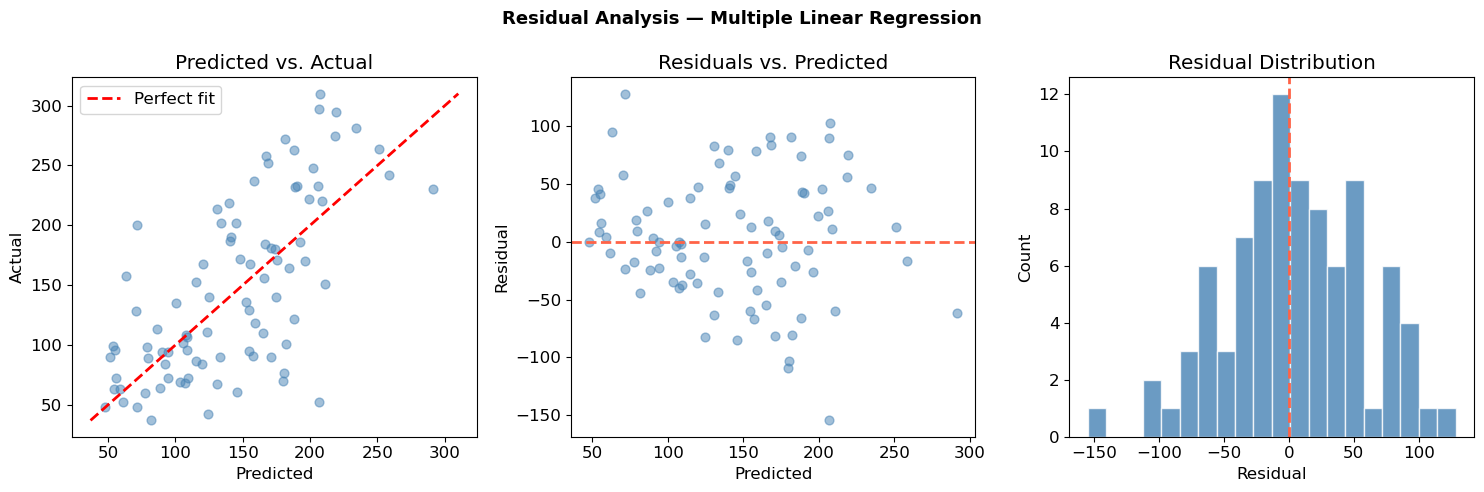

In [9]:
y_pred_test = lr.predict(X_test_s)
residuals   = y_test - y_pred_test

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Predicted vs actual
axes[0].scatter(y_pred_test, y_test, alpha=0.5, color='steelblue', s=40)
lims = [min(y_pred_test.min(), y_test.min()), max(y_pred_test.max(), y_test.max())]
axes[0].plot(lims, lims, 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Predicted vs. Actual'); axes[0].legend()

# Residuals vs predicted
axes[1].scatter(y_pred_test, residuals, alpha=0.5, color='steelblue', s=40)
axes[1].axhline(0, color='tomato', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals vs. Predicted')

# Residual distribution
axes[2].hist(residuals, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[2].axvline(0, color='tomato', linestyle='--', lw=2)
axes[2].set_xlabel('Residual'); axes[2].set_ylabel('Count')
axes[2].set_title('Residual Distribution')

plt.suptitle('Residual Analysis — Multiple Linear Regression', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Learned Coefficients

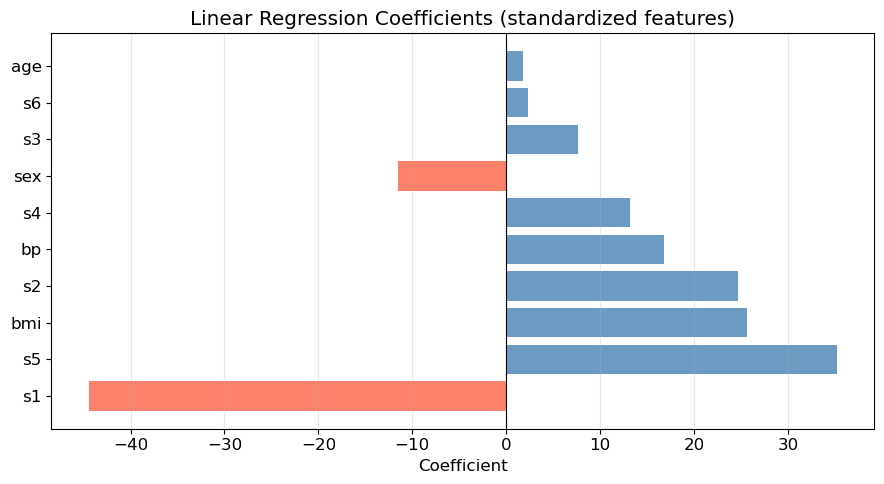

Intercept: 153.737
Feature  Coefficient
     s1   -44.448856
     s5    35.161195
    bmi    25.607121
     s2    24.640954
     bp    16.828872
     s4    13.138784
    sex   -11.511809
     s3     7.676978
     s6     2.351364
    age     1.753758


In [10]:
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': lr.coef_})
coef_df = coef_df.reindex(coef_df['Coefficient'].abs().sort_values(ascending=False).index)

bar_colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]

plt.figure(figsize=(9, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=bar_colors, alpha=0.8)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Coefficient')
plt.title('Linear Regression Coefficients (standardized features)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Intercept: {lr.intercept_:.3f}")
print(coef_df.to_string(index=False))

## 7. Ridge and Lasso Regression

**Regularization** addresses overfitting by penalizing large coefficients:

- **Ridge (L2):** $\mathcal{L} = \text{MSE} + \lambda \sum_j w_j^2$ — shrinks all coefficients, keeps all features
- **Lasso (L1):** $\mathcal{L} = \text{MSE} + \lambda \sum_j |w_j|$ — sets some coefficients exactly to zero (automatic feature selection)

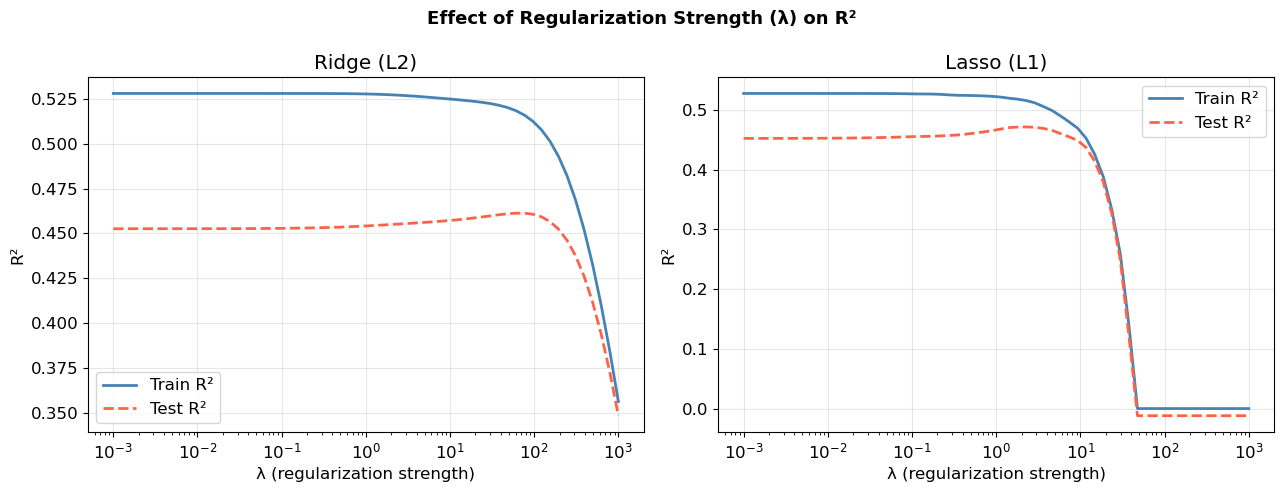

In [11]:
alphas = np.logspace(-3, 3, 60)
ridge_train, ridge_test = [], []
lasso_train, lasso_test = [], []

for a in alphas:
    ridge = Ridge(alpha=a).fit(X_train_s, y_train)
    ridge_train.append(r2_score(y_train, ridge.predict(X_train_s)))
    ridge_test.append(r2_score(y_test,  ridge.predict(X_test_s)))

    lasso = Lasso(alpha=a, max_iter=5000).fit(X_train_s, y_train)
    lasso_train.append(r2_score(y_train, lasso.predict(X_train_s)))
    lasso_test.append(r2_score(y_test,  lasso.predict(X_test_s)))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, train_acc, test_acc, name in [
    (axes[0], ridge_train, ridge_test, 'Ridge (L2)'),
    (axes[1], lasso_train, lasso_test, 'Lasso (L1)'),
]:
    ax.semilogx(alphas, train_acc, '-',  color='steelblue', lw=2, label='Train R²')
    ax.semilogx(alphas, test_acc,  '--', color='tomato',    lw=2, label='Test R²')
    ax.set_xlabel('λ (regularization strength)')
    ax.set_ylabel('R²')
    ax.set_title(name)
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Effect of Regularization Strength (λ) on R²', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Lasso Coefficient Paths

As $\lambda$ increases, Lasso drives coefficients to zero — revealing which features are most important.

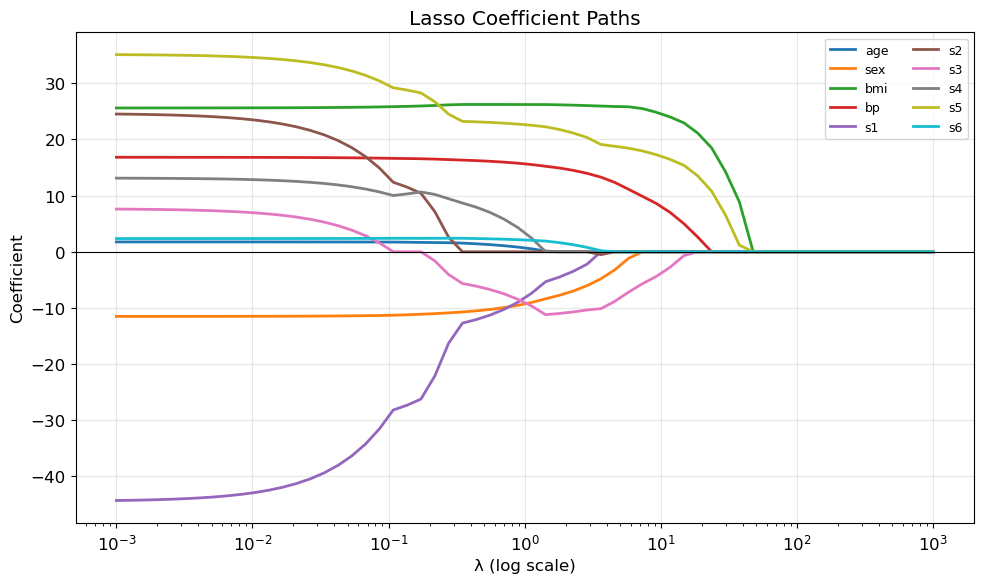

In [12]:
coef_paths = np.array([
    Lasso(alpha=a, max_iter=5000).fit(X_train_s, y_train).coef_
    for a in alphas
])

plt.figure(figsize=(10, 6))
for i, feat in enumerate(feature_names):
    plt.semilogx(alphas, coef_paths[:, i], lw=2, label=feat)
plt.axhline(0, color='black', lw=0.8)
plt.xlabel('λ (log scale)')
plt.ylabel('Coefficient')
plt.title('Lasso Coefficient Paths')
plt.legend(loc='upper right', fontsize=9, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary

| Model | Test R² | Test RMSE |
|-------|---------|----------|
| Simple LR (BMI only) | ~0.34 | ~60 |
| Multiple LR (all features) | ~0.52 | ~54 |
| Ridge (tuned λ) | ~0.52 | ~53 |

### Key Takeaways

- The **Normal Equation** gives an exact closed-form solution — no iterative optimization needed.
- Using more relevant features improves R² significantly over a single-feature model.
- **Residual plots** diagnose whether the linear assumption holds — random scatter around zero is good.
- **Ridge (L2)** shrinks all coefficients toward zero, reducing variance without eliminating any feature.
- **Lasso (L1)** produces sparse solutions by driving weak features' coefficients exactly to zero — useful for feature selection.
- **Standardizing features** is important for regularized regression so the penalty is applied evenly.